In [1]:
import ROOT
import uproot
import numpy as np
import awkward as ak

Welcome to JupyROOT 6.26/06


In [2]:
file_path = 'Data/merged_mc_v1.3.root'
tree_name  = "Tree"

CHARGED_IDS = [11, 13, 211, 321, 2212]

branches = [
    "PassAll",
    "GenStatus", "GenID", "GenPx", "GenPy", "GenPz", "GenMatchIndex", "GenMatchAngle",
    "RecoCharge", "RecoGoodTrack", "RecoPx", "RecoPy", "RecoPz",
    "RecoPIDPion", "RecoPIDKaon", "RecoPIDProton",
]

In [3]:
BinsX = np.array([
    -1.000, -0.940, -0.910, -0.820, -0.700, -0.675,
    -0.650, -0.625, -0.575, -0.550, -0.525, -0.500,
    -0.475, -0.450, -0.400, -0.375, -0.350, -0.325,
    -0.300, -0.275, -0.250, -0.225, -0.200, -0.175,
    -0.150, -0.050,
     0.050,  0.150,  0.175,  0.200,  0.225,
     0.250,  0.275,  0.300,  0.325,  0.350,  0.375,  0.400,
     0.425,  0.450,  0.475,  0.500,  0.525,  0.550,  0.575,
     0.600,  0.625,  0.650,  0.675,  0.700,  0.820,  0.910,  0.940,  1.000
], dtype=np.float64)

BinsY = np.array([
    0.000, 0.150, 0.250, 0.300, 0.350, 0.450, 0.500, 0.600, 0.718, 0.800, 0.900, 0.990, 1.000,
    1.100, 1.200, 1.300, 1.400, 1.500, 1.600, 1.800, 2.000, 2.200,
    2.300, 2.500, 2.600, 2.800, 2.900, 3.100, 3.300, 3.600, 4.000,
    4.500, 5.000, 5.500, 6.000, 6.500, 7.000, 7.500, 8.000, 10.000, 15.000, 25.000, 100.000
], dtype=np.float64)

NBinsX = len(BinsX) - 1
NBinsY = len(BinsY) - 1

print(f"X bins: {NBinsX}  (from {BinsX[0]:.3f} to {BinsX[-1]:.3f})")
print(f"Y bins: {NBinsY}  (from {BinsY[0]:.3f} to {BinsY[-1]:.3f} GeV)")

X bins: 53  (from -1.000 to 1.000)
Y bins: 42  (from 0.000 to 100.000 GeV)


In [4]:
def make_h2(name, title):
    h = ROOT.TH2D(name, title, NBinsX, BinsX, NBinsY, BinsY)
    h.Sumw2()
    return h

h_gen            = make_h2("h_gen",            "All Gen; cos(#theta); P [GeV]")
h_gen_matched    = make_h2("h_gen_matched",     "Matched Gen; cos(#theta); P [GeV]")
h_gen_unmatched  = make_h2("h_gen_unmatched",   "Unmatched Gen; cos(#theta); P [GeV]")
h_reco           = make_h2("h_reco",            "All Reco; cos(#theta); P [GeV]")
h_reco_matched   = make_h2("h_reco_matched",    "Matched Reco; cos(#theta); P [GeV]")
h_reco_unmatched = make_h2("h_reco_unmatched",  "Unmatched Reco; cos(#theta); P [GeV]")

particles = ["pion", "kaon", "proton"]


gen_hists   = {p: make_h2(f"HGen{p.capitalize()}",        f"Gen {p}; cos(#theta); P [GeV]") for p in particles}
gen_matched = {p: make_h2(f"HGen{p.capitalize()}Matched", f"Matched Gen {p}; cos(#theta); P [GeV]") for p in particles}


pid_tagged = {}
for true_p in particles:
    for tag_p in particles:
        key  = f"{true_p}_tag_{tag_p}"
        name = f"HGen{true_p.capitalize()}Matched{tag_p.capitalize()}Tagged"
        pid_tagged[key] = make_h2(name, f"Gen {true_p} matched, tagged as {tag_p}; cos(#theta); P [GeV]")


reco_hists   = {p: make_h2(f"HReco{p.capitalize()}",        f"Reco {p} (tagged); cos(#theta); P [GeV]") for p in particles}
reco_matched = {p: make_h2(f"HReco{p.capitalize()}Matched", f"Reco {p} matched; cos(#theta); P [GeV]") for p in particles}

all_hists = (
    [h_gen, h_gen_matched, h_gen_unmatched,
     h_reco, h_reco_matched, h_reco_unmatched]
    + list(gen_hists.values())
    + list(gen_matched.values())
    + list(pid_tagged.values())
    + list(reco_hists.values())
    + list(reco_matched.values())
)
print(f"Total histograms: {len(all_hists)}")

Total histograms: 27


In [5]:
pid_id     = {"pion": 211, "kaon": 321, "proton": 2212}
tag_branch = {"pion": "RecoPIDPion", "kaon": "RecoPIDKaon", "proton": "RecoPIDProton"}

def fill2d(h, x_arr, y_arr):
    """Fill TH2D from numpy arrays using FillN (fast) with scalar fallback."""
    x_arr = np.asarray(x_arr, dtype=np.float64)
    y_arr = np.asarray(y_arr, dtype=np.float64)
    if x_arr.size == 0:
        return
    w = np.ones(x_arr.size, dtype=np.float64)
    h.FillN(x_arr.size, x_arr, y_arr, w)

for h in all_hists:
    h.Reset()

for batch in uproot.iterate(f"{file_path}:{tree_name}", branches, step_size="100 MB"):

    events = batch[batch["PassAll"] == 1]
    n_ev   = len(events)
    if n_ev == 0:
        continue

    # ----------------------------------------------------------------
    # RECO: good-track
    # ----------------------------------------------------------------
    reco_px = events["RecoPx"]; reco_py = events["RecoPy"]; reco_pz = events["RecoPz"]
    reco_p  = np.sqrt(reco_px**2 + reco_py**2 + reco_pz**2)
    reco_pt = np.sqrt(reco_px**2 + reco_py**2)
    with np.errstate(divide='ignore', invalid='ignore'):
        reco_ct = np.nan_to_num(reco_pz / reco_p, nan=0.0)

    mask_reco_good = (
        (events["RecoCharge"]    != 0) &
        (events["RecoGoodTrack"] >  0) &
        (reco_pt >= 0.4) & (reco_pt <= 100) &
        (np.abs(reco_ct) < 0.95)
    )

    reco_counts    = ak.to_numpy(ak.num(reco_p))
    reco_event_idx = np.repeat(np.arange(n_ev), reco_counts)
    reco_local_idx = ak.to_numpy(ak.flatten(ak.local_index(reco_p)))
    reco_gid_all   = reco_event_idx.astype(np.int64) * 1_000_000 + reco_local_idx.astype(np.int64)

    flat_reco_good = ak.to_numpy(ak.flatten(mask_reco_good))
    flat_reco_p    = ak.to_numpy(ak.flatten(reco_p))
    flat_reco_ct   = ak.to_numpy(ak.flatten(reco_ct))
    flat_pid_all   = {sp: ak.to_numpy(ak.flatten(events[tag_branch[sp]])) for sp in particles}

    good_reco_ids = reco_gid_all[flat_reco_good]
    good_reco_p   = flat_reco_p[flat_reco_good]
    good_reco_ct  = flat_reco_ct[flat_reco_good]
    good_pid      = {sp: flat_pid_all[sp][flat_reco_good] for sp in particles}

    # Pre-sort good reco IDs once — reused for all searchsorted calls this batch
    sort_good        = np.argsort(good_reco_ids)
    good_ids_sorted  = good_reco_ids[sort_good]

    # ----------------------------------------------------------------
    # GEN: charged and status == 1
    # ----------------------------------------------------------------
    gen_px = events["GenPx"]; gen_py = events["GenPy"]; gen_pz = events["GenPz"]
    gen_id = events["GenID"]
    gen_p  = np.sqrt(gen_px**2 + gen_py**2 + gen_pz**2)
    with np.errstate(divide='ignore', invalid='ignore'):
        gen_ct = np.nan_to_num(gen_pz / gen_p, nan=0.0)

    gen_counts    = ak.to_numpy(ak.num(gen_p))
    gen_event_idx = np.repeat(np.arange(n_ev), gen_counts)

    flat_gen_p   = ak.to_numpy(ak.flatten(gen_p))
    flat_gen_ct  = ak.to_numpy(ak.flatten(gen_ct))
    flat_gen_id  = ak.to_numpy(ak.flatten(gen_id))
    flat_gen_st  = ak.to_numpy(ak.flatten(events["GenStatus"]))
    flat_midx    = ak.to_numpy(ak.flatten(events["GenMatchIndex"]))
    flat_mang    = ak.to_numpy(ak.flatten(events["GenMatchAngle"]))


    abs_gid    = np.abs(flat_gen_id)
    is_charged = np.isin(abs_gid, [11, 13, 211, 321, 2212]) 
    mask_gen   = (flat_gen_st == 1) & is_charged

    # Gen denominators
    sel_p  = flat_gen_p[mask_gen]
    sel_ct = flat_gen_ct[mask_gen]
    sel_id = flat_gen_id[mask_gen]

    fill2d(h_gen, sel_ct, sel_p)
    for sp, pdg in pid_id.items():
        m = (np.abs(sel_id) == pdg)
        fill2d(gen_hists[sp], sel_ct[m], sel_p[m])

    # ----------------------------------------------------------------
    # MATCH: angle < 0.01, index >= 0, reco passes good-track cuts
    # ----------------------------------------------------------------
    cand_reco_gid = gen_event_idx.astype(np.int64) * 1_000_000 + flat_midx.astype(np.int64)

    cand_ok = (
        mask_gen &
        (flat_mang < 0.01) &
        (flat_midx >= 0) &
        np.isin(cand_reco_gid, good_reco_ids)
    )

    final_reco   = cand_reco_gid[cand_ok]
    final_gen_p  = flat_gen_p[cand_ok]
    final_gen_ct = flat_gen_ct[cand_ok]
    final_gen_id = flat_gen_id[cand_ok]

    # Matched gen histograms
    fill2d(h_gen_matched, final_gen_ct, final_gen_p)
    for sp, pdg in pid_id.items():
        m = (np.abs(final_gen_id) == pdg)
        fill2d(gen_matched[sp], final_gen_ct[m], final_gen_p[m])

    # Unmatched gen
    unmatched_gen_mask = mask_gen & ~cand_ok
    fill2d(h_gen_unmatched, flat_gen_ct[unmatched_gen_mask], flat_gen_p[unmatched_gen_mask])

    # ----------------------------------------------------------------
    # RECO matched
    # ----------------------------------------------------------------
    good_reco_is_matched = np.isin(good_reco_ids, final_reco)

    fill2d(h_reco,           good_reco_ct,                         good_reco_p)
    fill2d(h_reco_matched,   good_reco_ct[good_reco_is_matched],   good_reco_p[good_reco_is_matched])
    fill2d(h_reco_unmatched, good_reco_ct[~good_reco_is_matched],  good_reco_p[~good_reco_is_matched])

    for sp in particles:
        tag       = (good_pid[sp] >= 2)
        match_tag = good_reco_is_matched & tag
        fill2d(reco_hists[sp],   good_reco_ct[tag],       good_reco_p[tag])
        fill2d(reco_matched[sp], good_reco_ct[match_tag], good_reco_p[match_tag])

    # ----------------------------------------------------------------
    # PID MATRIX
    # ----------------------------------------------------------------
    if final_reco.size > 0:

        pos = np.searchsorted(good_ids_sorted, final_reco)

        in_bounds = (pos < good_ids_sorted.size)

        valid = np.zeros(final_reco.size, dtype=bool)
        valid[in_bounds] = (good_ids_sorted[pos[in_bounds]] == final_reco[in_bounds])

        if np.any(valid):
            good_idx = sort_good[pos[valid]]

            gen_id_v  = final_gen_id[valid]
            gen_p_v   = final_gen_p[valid]
            gen_ct_v  = final_gen_ct[valid]

            for true_sp, pdg in pid_id.items():
                true_mask = (np.abs(gen_id_v) == pdg)
                if not np.any(true_mask):
                    continue
                for tag_sp in particles:
                    tag_mask = (good_pid[tag_sp][good_idx] >= 2)
                    num_mask = true_mask & tag_mask
                    fill2d(
                        pid_tagged[f"{true_sp}_tag_{tag_sp}"],
                        gen_ct_v[num_mask],
                        gen_p_v[num_mask]
                    )

In [6]:
for sp in particles:
    g  = gen_hists[sp].Integral()
    gm = gen_matched[sp].Integral()
    r  = reco_hists[sp].Integral()
    rm = reco_matched[sp].Integral()
    pd_denom = gen_matched[sp].Integral()
    pd_num   = pid_tagged[f"{sp}_tag_{sp}"].Integral()
    print(f"\n{sp.upper()}")
    print(f"  gen all             : {g:.0f}")
    print(f"  gen matched         : {gm:.0f}   match_eff={gm/g:.4f}" if g > 0 else "  gen=0!")
    print(f"  reco tagged         : {r:.0f}")
    print(f"  reco tagged matched : {rm:.0f}   fake_rate={(r-rm)/r:.4f}  purity={rm/r:.4f}" if r > 0 else "  reco=0!")
    print(f"  PID denom (matched) : {pd_denom:.0f}")
    print(f"  PID num (→{sp})      : {pd_num:.0f}   tag_eff={pd_num/pd_denom:.4f}" if pd_denom > 0 else "  PID denom=0!")

# Consistency checks
for sp in particles:
    ok_eff  = ROOT.TEfficiency.CheckConsistency(gen_matched[sp],   gen_hists[sp])
    ok_fake = ROOT.TEfficiency.CheckConsistency(
        # fake = unmatched tagged = reco_hists - reco_matched
        reco_hists[sp],
        reco_hists[sp])

    # unmatched = reco_hists[sp] - reco_matched[sp]  (bin-by-bin)
    pass

print("\nConsistency (gen_matched ≤ gen):")
for sp in particles:
    ok = ROOT.TEfficiency.CheckConsistency(gen_matched[sp], gen_hists[sp])
    print(f"  {sp}: {'OK' if ok else 'FAIL'}")


PION
  gen all             : 19640163
  gen matched         : 13417992   match_eff=0.6832
  reco tagged         : 10558601
  reco tagged matched : 8634487   fake_rate=0.1822  purity=0.8178
  PID denom (matched) : 13417992
  PID num (→pion)      : 8281830   tag_eff=0.6172

KAON
  gen all             : 2886534
  gen matched         : 2344788   match_eff=0.8123
  reco tagged         : 1945352
  reco tagged matched : 1712105   fake_rate=0.1199  purity=0.8801
  PID denom (matched) : 2344788
  PID num (→kaon)      : 1079463   tag_eff=0.4604

PROTON
  gen all             : 905179
  gen matched         : 731588   match_eff=0.8082
  reco tagged         : 932631
  reco tagged matched : 678241   fake_rate=0.2728  purity=0.7272
  PID denom (matched) : 731588
  PID num (→proton)      : 337529   tag_eff=0.4614

Consistency (gen_matched ≤ gen):
  pion: OK
  kaon: OK
  proton: OK


In [7]:
reco_unmatched_sp = {}
for sp in particles:
    h = reco_hists[sp].Clone(f"HReco{sp.capitalize()}Unmatched")
    h.Add(reco_matched[sp], -1.0)   # unmatched = total tagged reco - matched tagged reco
    h.SetTitle(f"Unmatched Reco {sp}; cos(#theta); P [GeV]")
    reco_unmatched_sp[sp] = h

print("Fake rate consistency (unmatched ≤ reco_tagged):")
for sp in particles:
    ok = ROOT.TEfficiency.CheckConsistency(reco_unmatched_sp[sp], reco_hists[sp])
    print(f"  {sp}: {'OK' if ok else 'FAIL'}")

Fake rate consistency (unmatched ≤ reco_tagged):
  pion: OK
  kaon: OK
  proton: OK


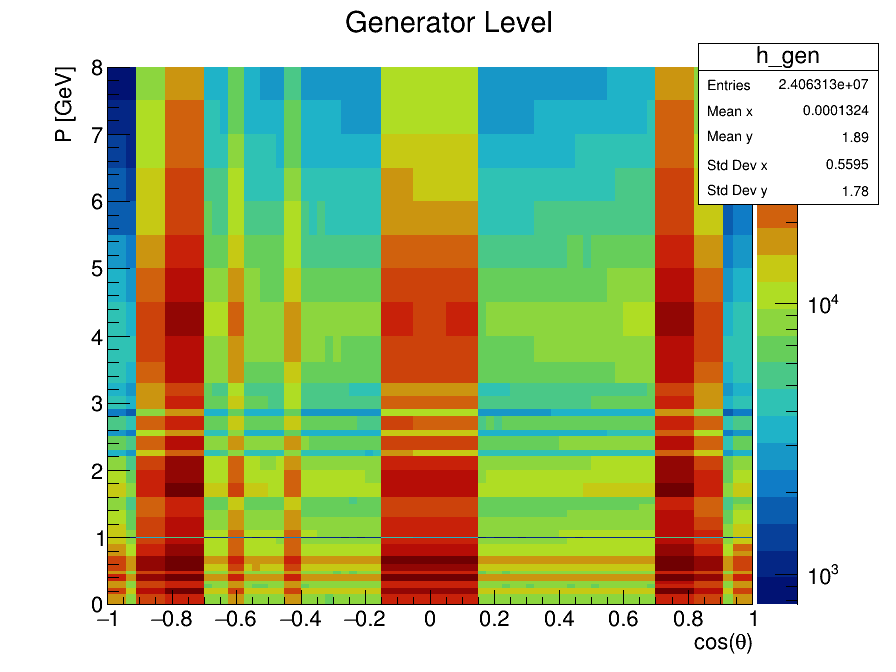

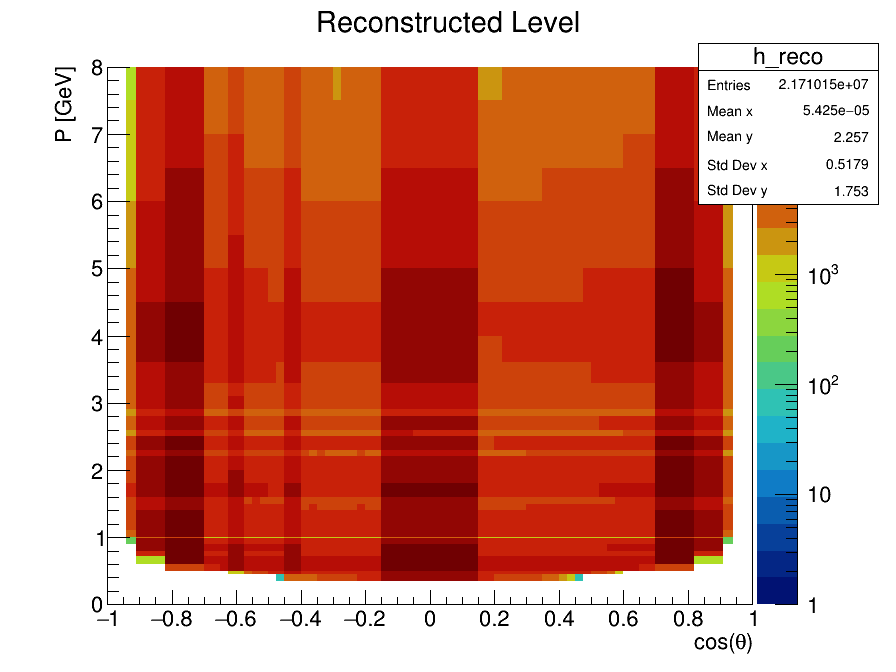

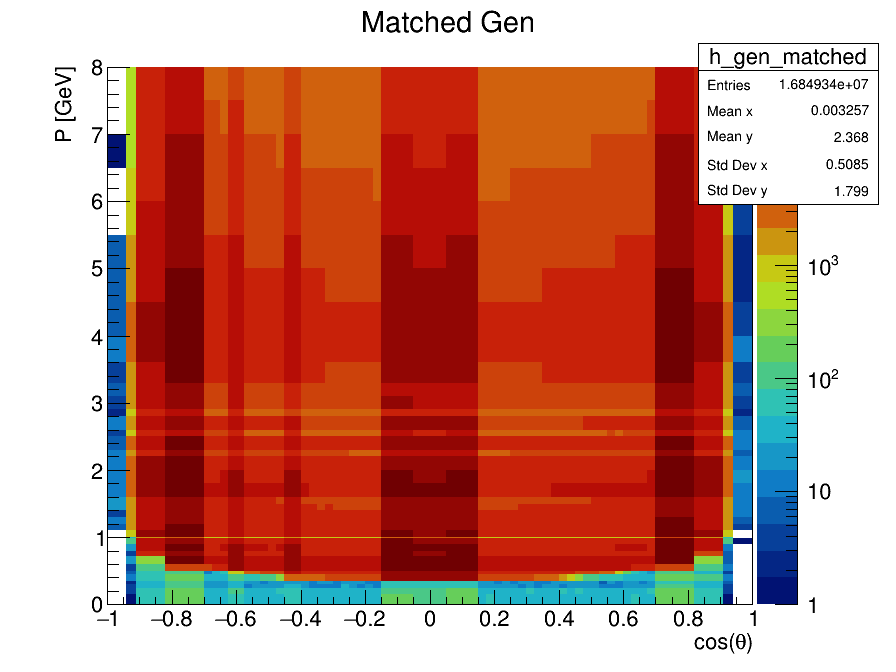

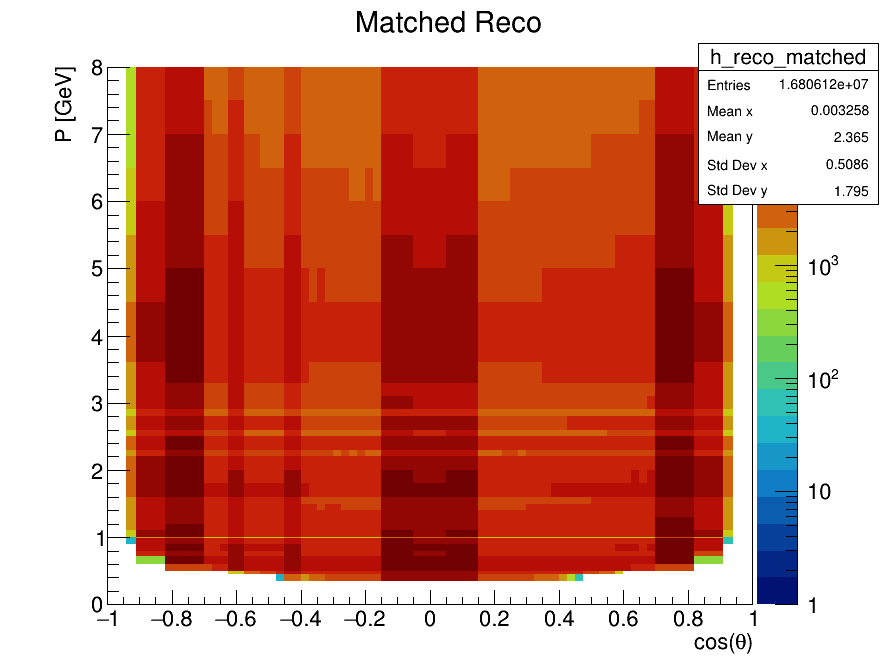

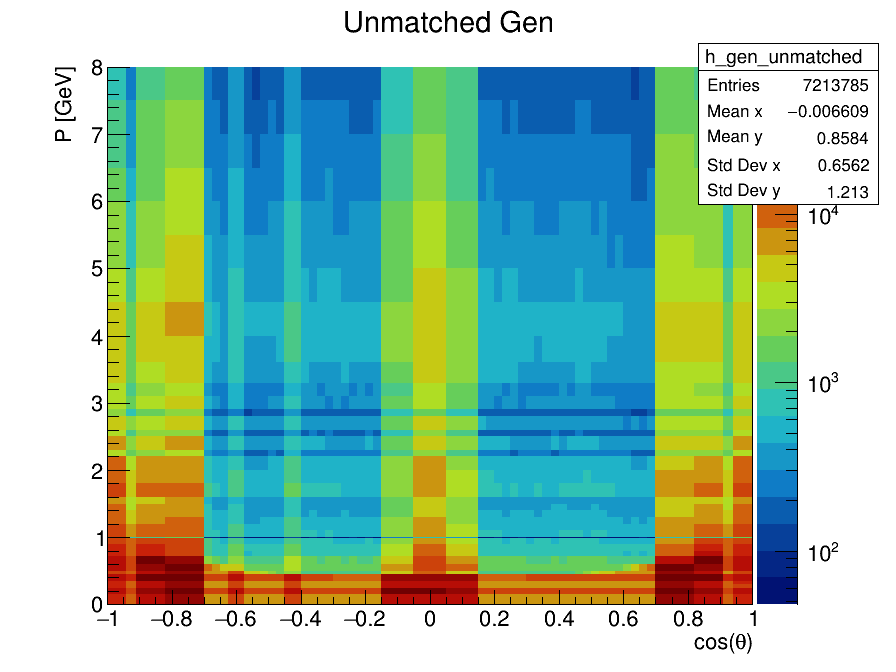

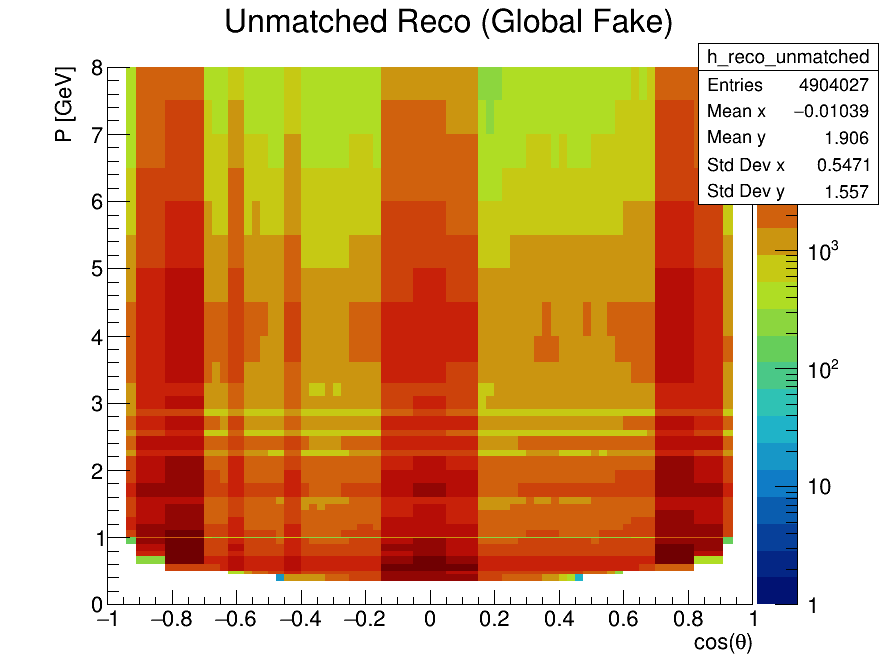

In [8]:
canvas_list = []
keep_alive  = []

def draw_canvas_2d(h, name, title, logz=True):
    c = ROOT.TCanvas(name, title, 900, 700)
    ROOT.gStyle.SetPalette(ROOT.kRainBow)
    ROOT.gPad.SetRightMargin(0.16)
    ROOT.gPad.SetLeftMargin(0.12)
    if logz:
        ROOT.gPad.SetLogz()
    h.SetTitle(title)
    h.GetXaxis().SetTitle("cos(#theta)")
    h.GetYaxis().SetTitle("P [GeV]")
    h.GetYaxis().SetRangeUser(0.0, 8.0)
    h.Draw("COLZ")
    c.Update()
    c.Draw()
    canvas_list.append(c)
    return c

c1 = draw_canvas_2d(h_gen,           "c_gen",   "Generator Level")
c2 = draw_canvas_2d(h_reco,          "c_reco",  "Reconstructed Level")
c3 = draw_canvas_2d(h_gen_matched,   "c_gm",    "Matched Gen")
c4 = draw_canvas_2d(h_reco_matched,  "c_rm",    "Matched Reco")
c5 = draw_canvas_2d(h_gen_unmatched, "c_gu",    "Unmatched Gen")
c6 = draw_canvas_2d(h_reco_unmatched,"c_ru",    "Unmatched Reco (Global Fake)")

Global Gen Efficiency: 0.6833  (15238854/22303293)
Global Fake Rate: 0.2348  (4667716/19879190)


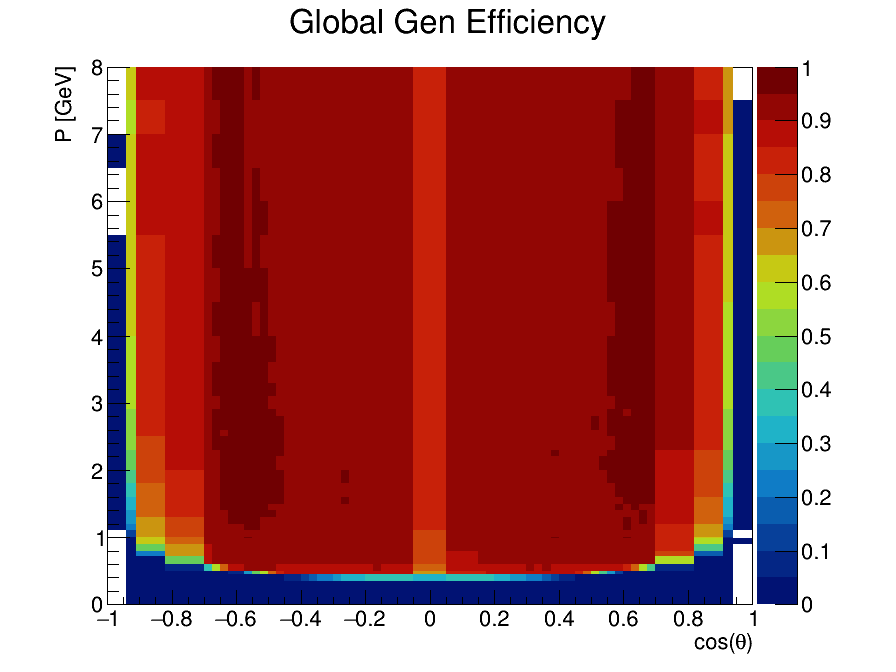

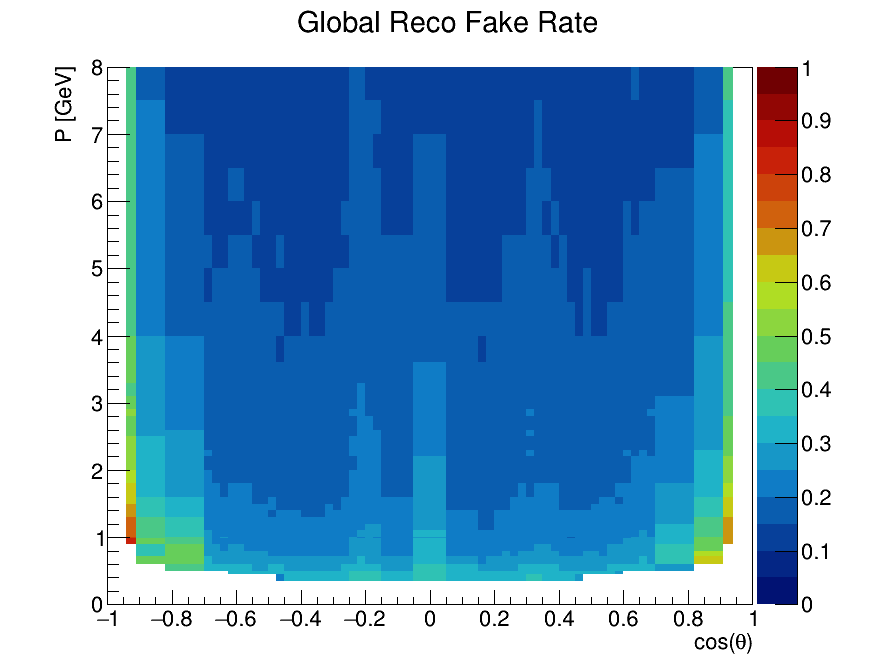

In [9]:
eff_list = []

def draw_teff_2d(num, denom, name, title, zmax=1.0, zmin=0.0):
    if not ROOT.TEfficiency.CheckConsistency(num, denom):
        print(f"WARNING: {name} inconsistent — skipping")
        return None
    pEff = ROOT.TEfficiency(num, denom)
    pEff.SetStatisticOption(ROOT.TEfficiency.kFCP)
    pEff.SetName(name)
    pEff.SetTitle(title)
    c = ROOT.TCanvas(f"c_{name}", title, 900, 700)
    ROOT.gStyle.SetPalette(ROOT.kRainBow)
    ROOT.gPad.SetRightMargin(0.16)
    ROOT.gPad.SetLeftMargin(0.12)
    pEff.Draw("COLZ")
    ROOT.gPad.Update()
    h = pEff.GetPaintedHistogram()
    if h:
        h.SetMinimum(zmin)
        h.SetMaximum(zmax)
        h.GetYaxis().SetRangeUser(0.0, 8.0)
    c.Draw()
    canvas_list.append(c)
    eff_list.append(pEff)
    keep_alive.extend([pEff, c])
    return c

# Global matching efficiency
draw_teff_2d(h_gen_matched, h_gen, "GenEff", "Global Gen Efficiency; cos(#theta); P [GeV]")
n = h_gen_matched.Integral(); d = h_gen.Integral()
print(f"Global Gen Efficiency: {n/d:.4f}  ({n:.0f}/{d:.0f})")

# Global fake rate
draw_teff_2d(h_reco_unmatched, h_reco, "RecoFakeRate", "Global Reco Fake Rate; cos(#theta); P [GeV]")
n = h_reco_unmatched.Integral(); d = h_reco.Integral()
print(f"Global Fake Rate: {n/d:.4f}  ({n:.0f}/{d:.0f})")

  pion: 0.6832  (13417992/19640163)
  kaon: 0.8123  (2344788/2886534)
  proton: 0.8082  (731588/905179)
  pion: 0.1822  (1924114/10558601)
  kaon: 0.1199  (233247/1945352)
  proton: 0.2728  (254390/932631)


Info in <TEfficiency::TEfficiency>: given histograms are filled with weights
Info in <TROOT::TEfficiency::SetUseWeightedEvents>: Handle weighted events for computing efficiency
Info in <TEfficiency::TEfficiency>: given histograms are filled with weights
Info in <TROOT::TEfficiency::SetUseWeightedEvents>: Handle weighted events for computing efficiency
Info in <TEfficiency::TEfficiency>: given histograms are filled with weights
Info in <TROOT::TEfficiency::SetUseWeightedEvents>: Handle weighted events for computing efficiency


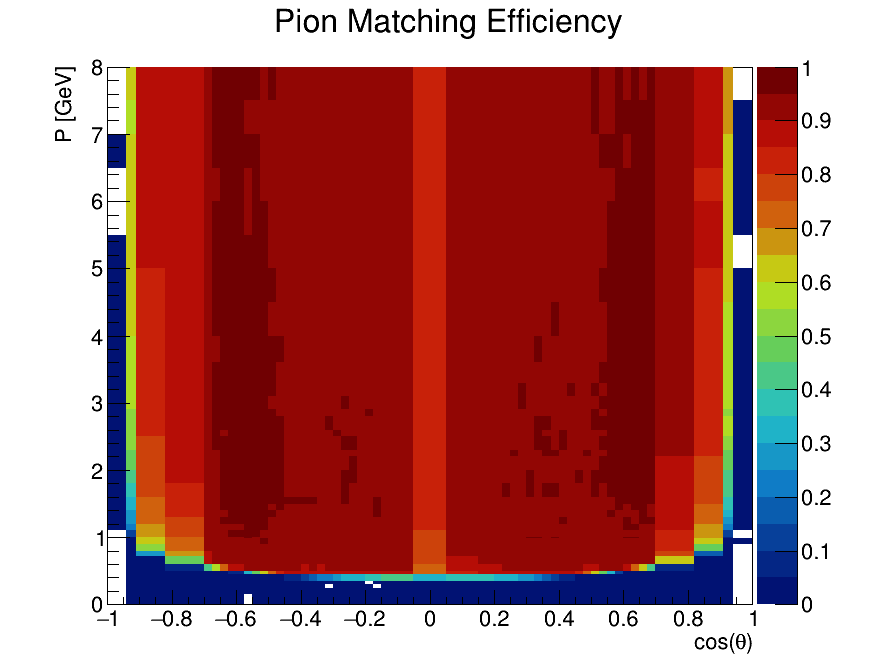

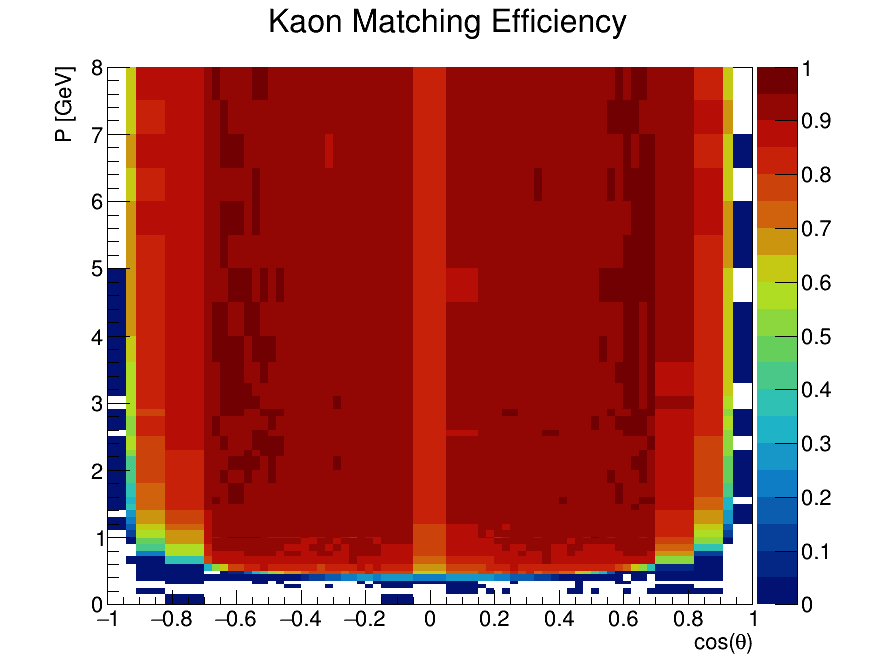

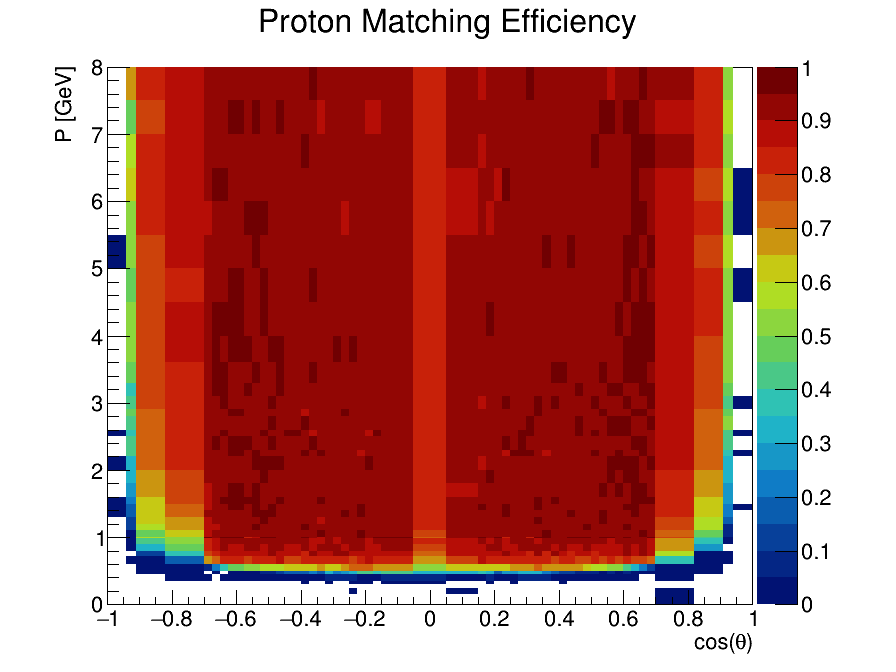

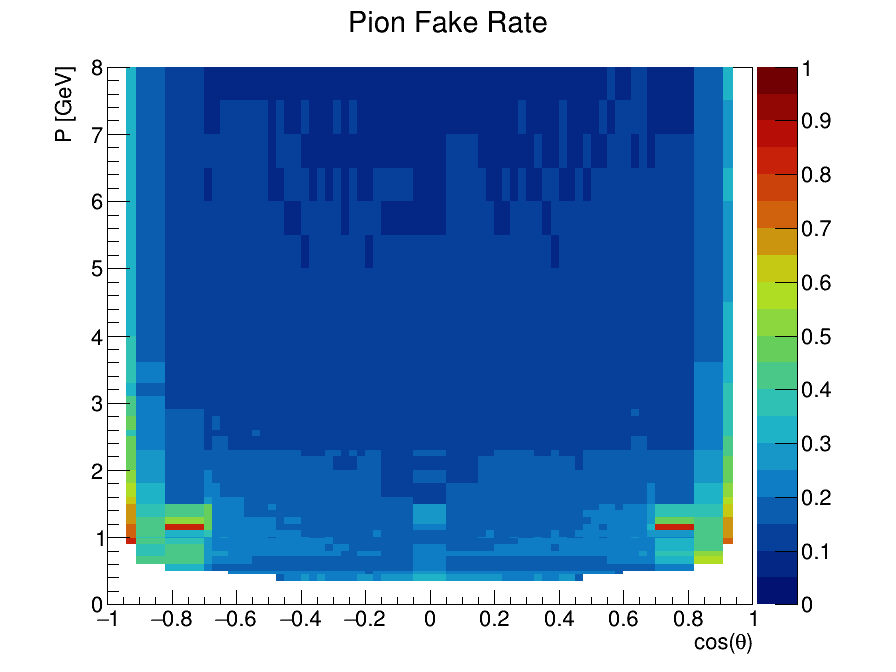

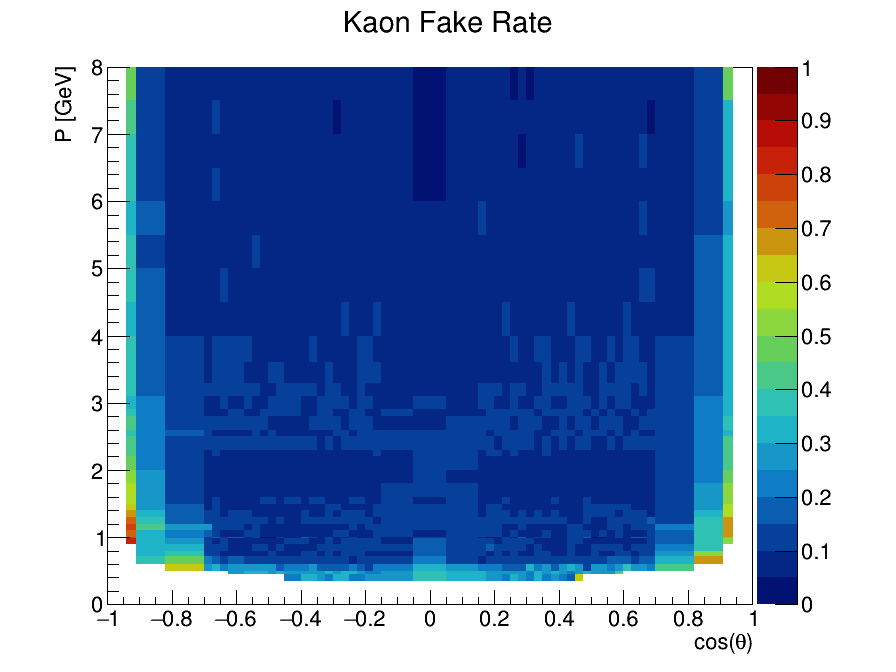

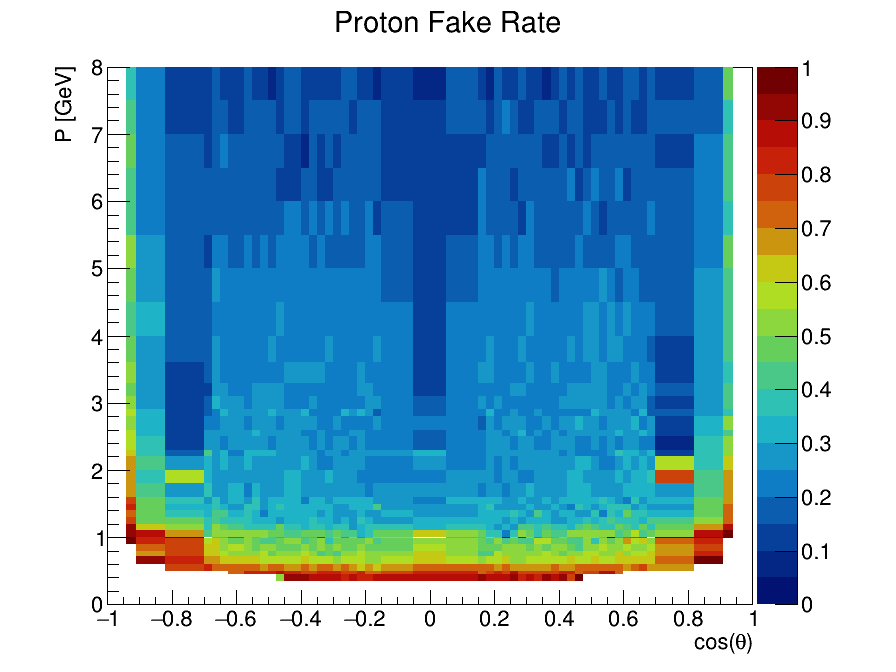

In [10]:
for sp in particles:
    draw_teff_2d(gen_matched[sp], gen_hists[sp], f"Eff_{sp}", f"{sp.capitalize()} Matching Efficiency")
    n = gen_matched[sp].Integral(); d = gen_hists[sp].Integral()
    print(f"  {sp}: {n/d:.4f}  ({n:.0f}/{d:.0f})")


for sp in particles:
    draw_teff_2d(reco_unmatched_sp[sp], reco_hists[sp], f"Fake_{sp}", f"{sp.capitalize()} Fake Rate")
    n = reco_unmatched_sp[sp].Integral(); d = reco_hists[sp].Integral()
    print(f"  {sp}: {n/d:.4f}  ({n:.0f}/{d:.0f})")


  TRUE PION  (denom=13417992)
    → tag pion   : Eff    8281830 / 13417992 = 0.6172
    → tag kaon   : MisID    562322 / 13417992 = 0.0419
    → tag proton : MisID    154177 / 13417992 = 0.0115

  TRUE KAON  (denom=2344788)
    → tag pion   : MisID    135042 / 2344788 = 0.0576
    → tag kaon   : Eff    1079463 / 2344788 = 0.4604
    → tag proton : MisID    182210 / 2344788 = 0.0777

  TRUE PROTON  (denom=731588)
    → tag pion   : MisID     33384 / 731588 = 0.0456
    → tag kaon   : MisID     60386 / 731588 = 0.0825
    → tag proton : Eff     337529 / 731588 = 0.4614


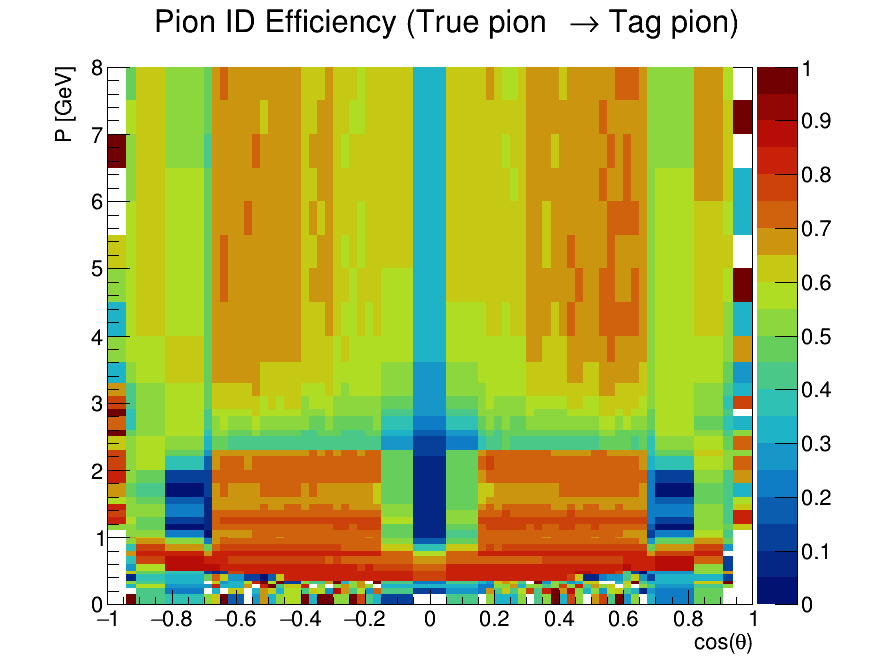

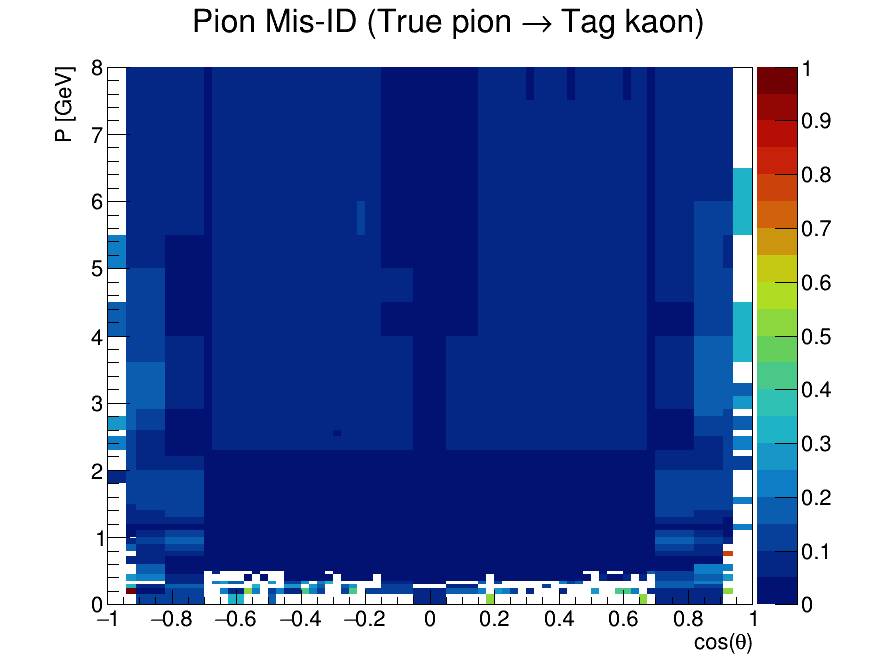

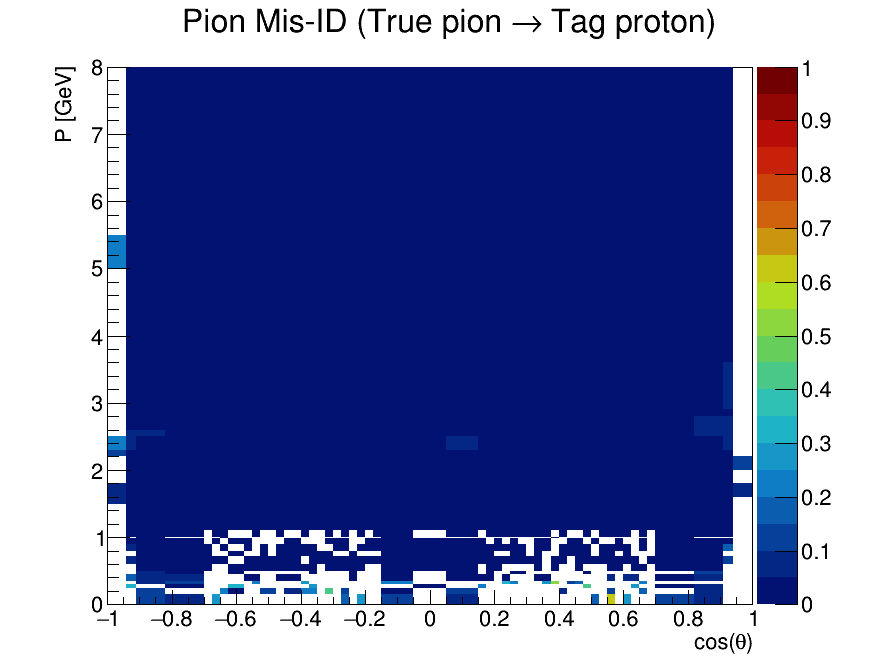

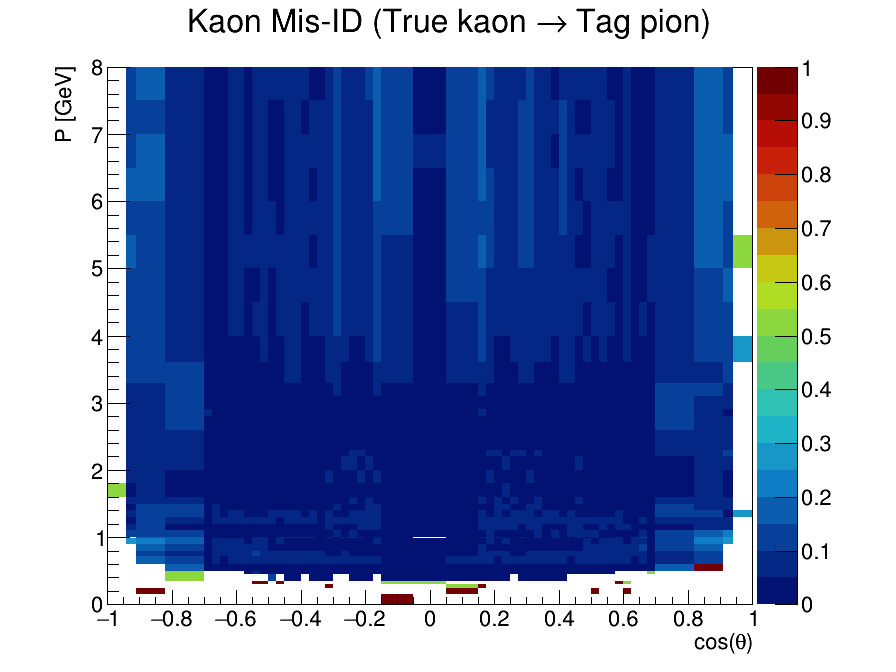

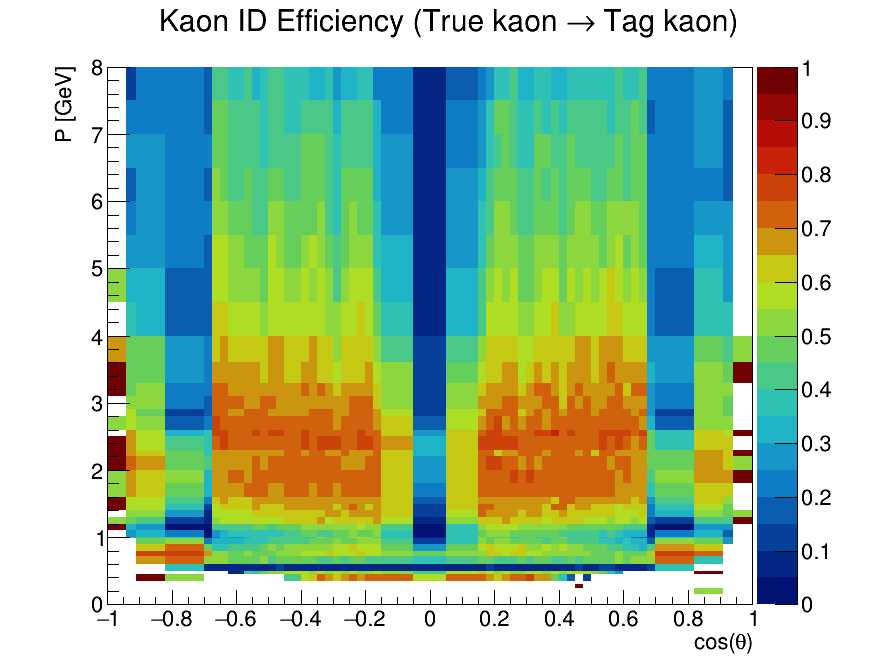

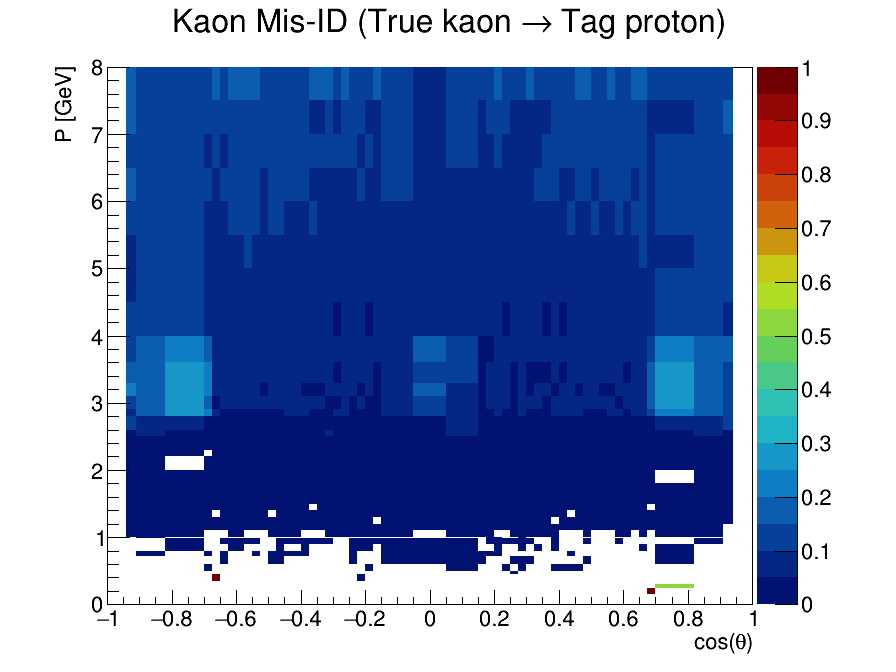

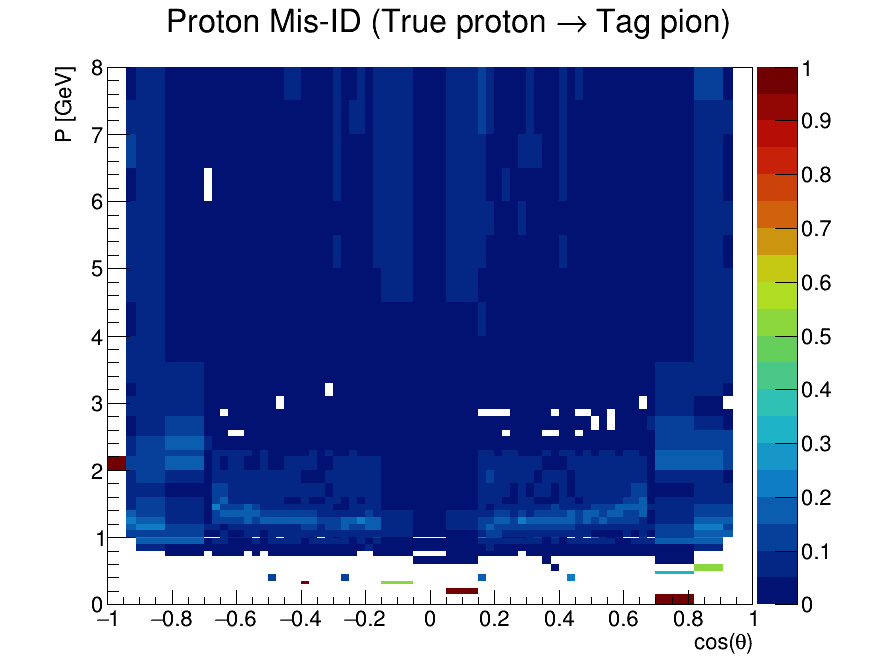

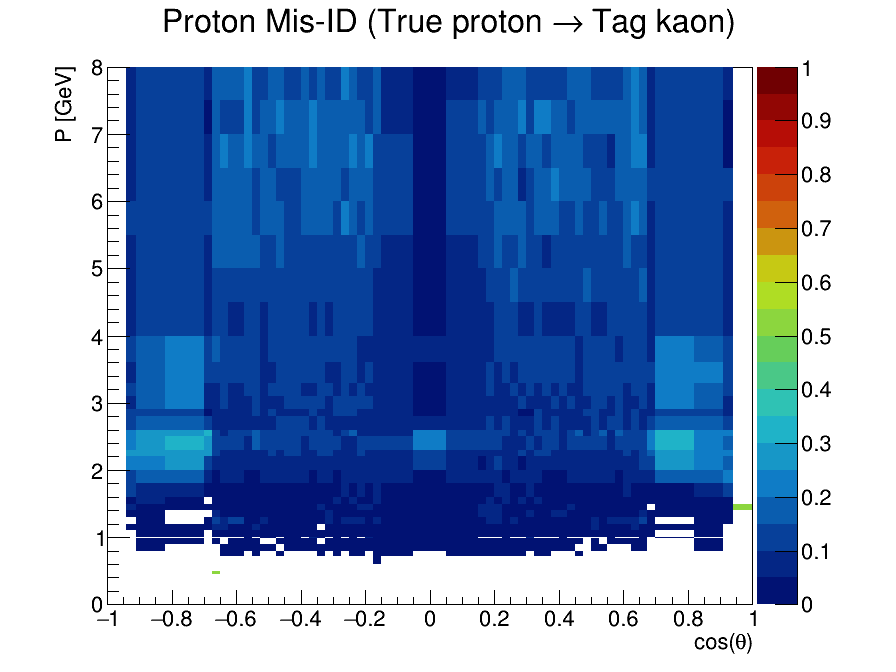

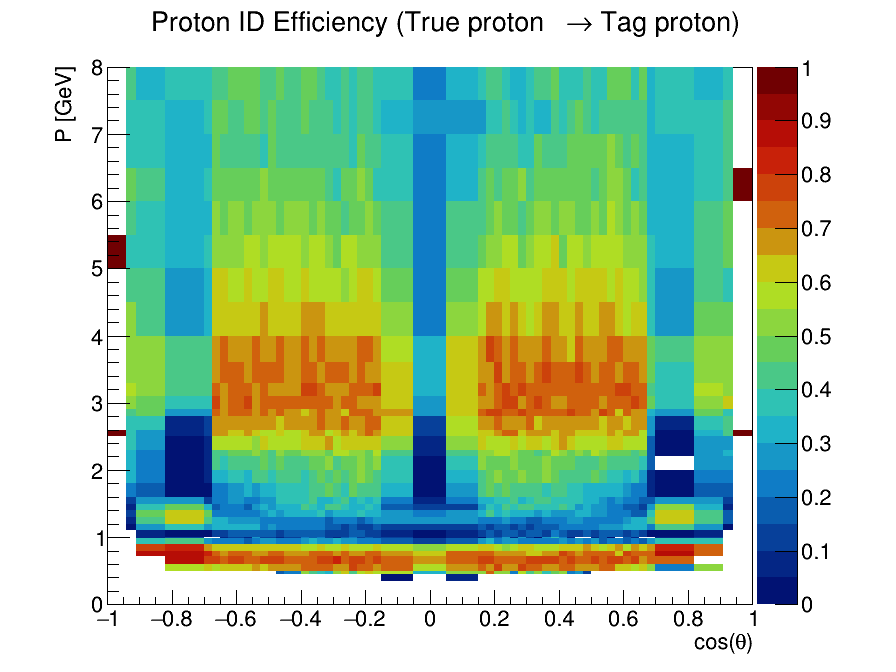

In [11]:
for true_sp in particles:
    denom = gen_matched[true_sp]
    d_int = denom.Integral()
    print(f"\n  TRUE {true_sp.upper()}  (denom={d_int:.0f})")
    for tag_sp in particles:
        num   = pid_tagged[f"{true_sp}_tag_{tag_sp}"]
        n_int = num.Integral()
        label = "Eff " if true_sp == tag_sp else "MisID"
        frac  = n_int / d_int if d_int > 0 else 0
        print(f"    → tag {tag_sp:<7}: {label}  {n_int:8.0f} / {d_int:.0f} = {frac:.4f}")

        plot_name  = f"Eff_{true_sp}_ID"        if true_sp == tag_sp else f"MisID_{true_sp}_as_{tag_sp}"
        plot_title = (f"{true_sp.capitalize()} ID Efficiency (True {true_sp} #rightarrow Tag {tag_sp})"
                      if true_sp == tag_sp else
                      f"{true_sp.capitalize()} Mis-ID (True {true_sp} #rightarrow Tag {tag_sp})")
        draw_teff_2d(num, denom, plot_name, plot_title + "; cos(#theta); P [GeV]")

In [12]:
# SAVE TO ROOT FILE — Variable Binning

output_filename = "MC_Merged_Matched_EfficiencyVariableBinning_FakeRate.root"
f_out = ROOT.TFile(output_filename, "RECREATE")
f_out.cd()

for h in all_hists:
    h.Write()

for sp in particles:
    reco_unmatched_sp[sp].Write()

written_names = set()
for obj in list(eff_list) + keep_alive:
    if isinstance(obj, ROOT.TEfficiency):
        if obj.GetName() not in written_names:
            obj.Write()
            written_names.add(obj.GetName())

f_out.Close()
print(f"Saved: {output_filename}")

Saved: MC_Merged_Matched_EfficiencyVariableBinning_FakeRate.root


In [13]:
f = ROOT.TFile.Open(output_filename)
if not f or f.IsZombie():
    print("Error: Could not open file.")
else:
    print(f"\nFile size: {f.GetSize() / 1024:.2f} KB")
    print("-" * 100)
    print(f"{'Class':<20} | {'Name':<40} | {'Title'}")
    print("-" * 100)
    for key in f.GetListOfKeys():
        print(f"{key.GetClassName():<20} | {key.GetName():<40} | {key.GetTitle()}")
    print("-" * 100)
    print(f"Total objects: {f.GetListOfKeys().GetEntries()}")
    f.Close()


File size: 486.40 KB
----------------------------------------------------------------------------------------------------
Class                | Name                                     | Title
----------------------------------------------------------------------------------------------------
TH2D                 | h_gen                                    | Generator Level
TH2D                 | h_gen_matched                            | Matched Gen
TH2D                 | h_gen_unmatched                          | Unmatched Gen
TH2D                 | h_reco                                   | Reconstructed Level
TH2D                 | h_reco_matched                           | Matched Reco
TH2D                 | h_reco_unmatched                         | Unmatched Reco (Global Fake)
TH2D                 | HGenPion                                 | Gen pion
TH2D                 | HGenKaon                                 | Gen kaon
TH2D                 | HGenProton                     


--- Generating Momentum (P) Plots ---
[PION  ]     P-projection Global Ratio = 1.0181
[KAON  ]     P-projection Global Ratio = 1.0060
[PROTON]     P-projection Global Ratio = 1.0023

--- Generating Angular (cosTheta) Plots ---
[PION  ] costh-projection Global Ratio = 1.0192
[KAON  ] costh-projection Global Ratio = 1.0056
[PROTON] costh-projection Global Ratio = 1.0029


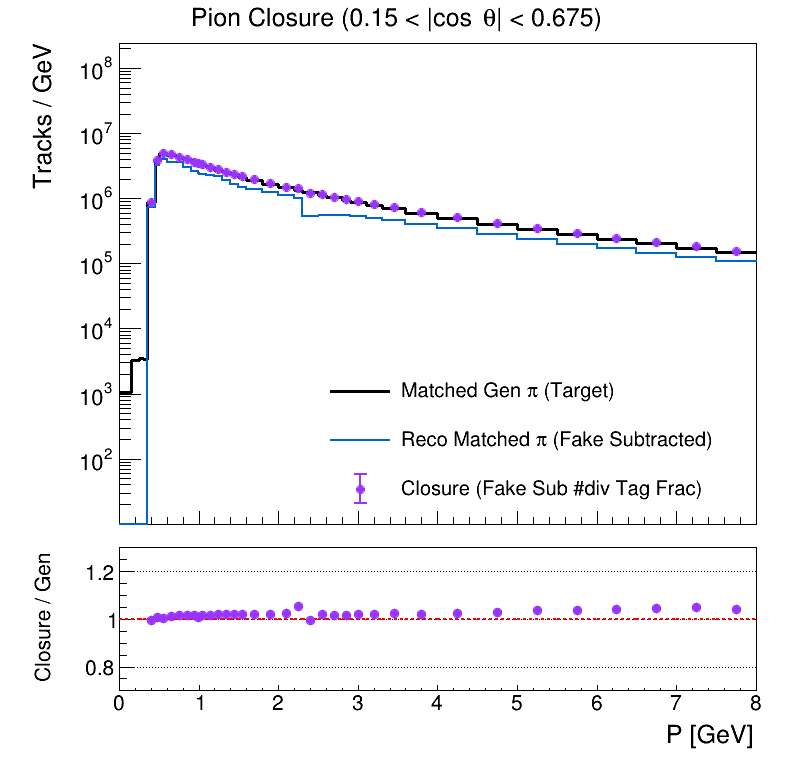

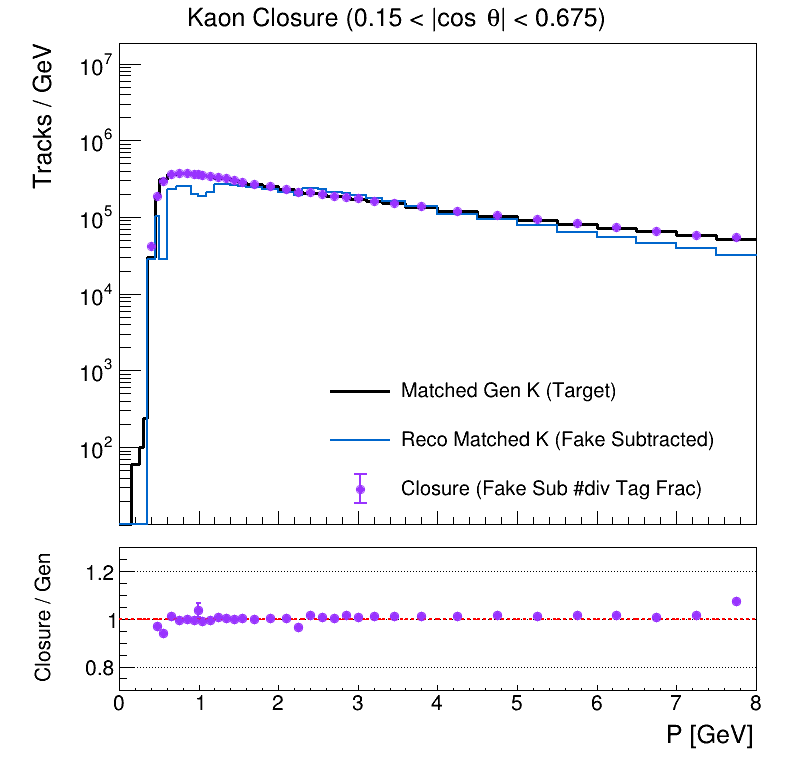

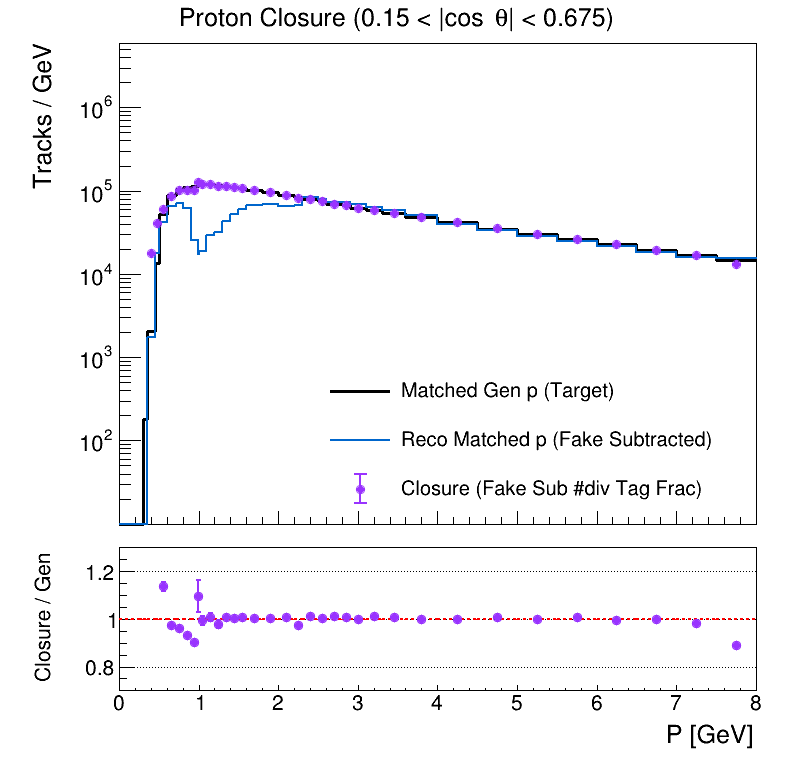

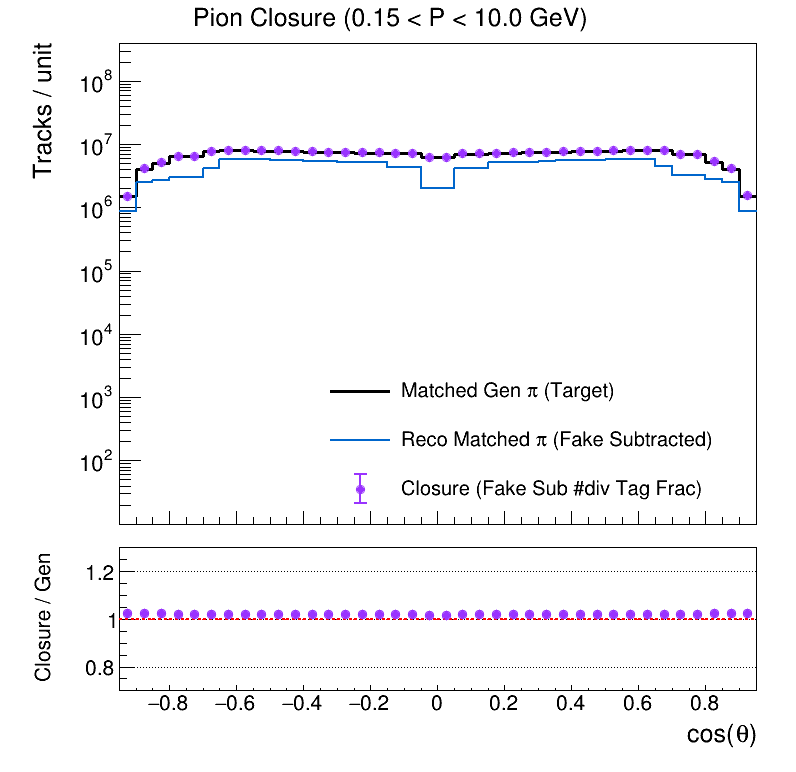

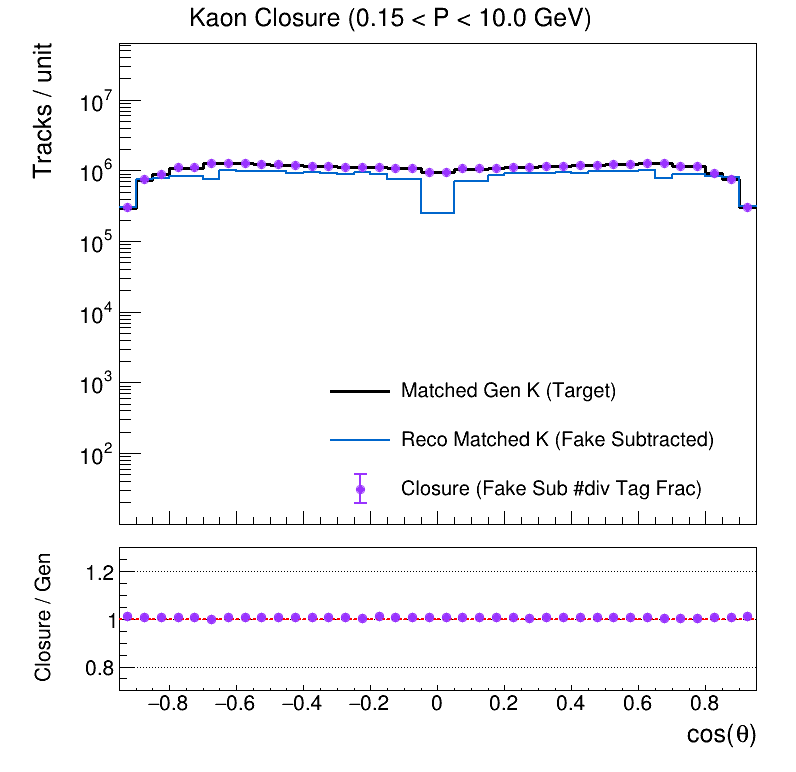

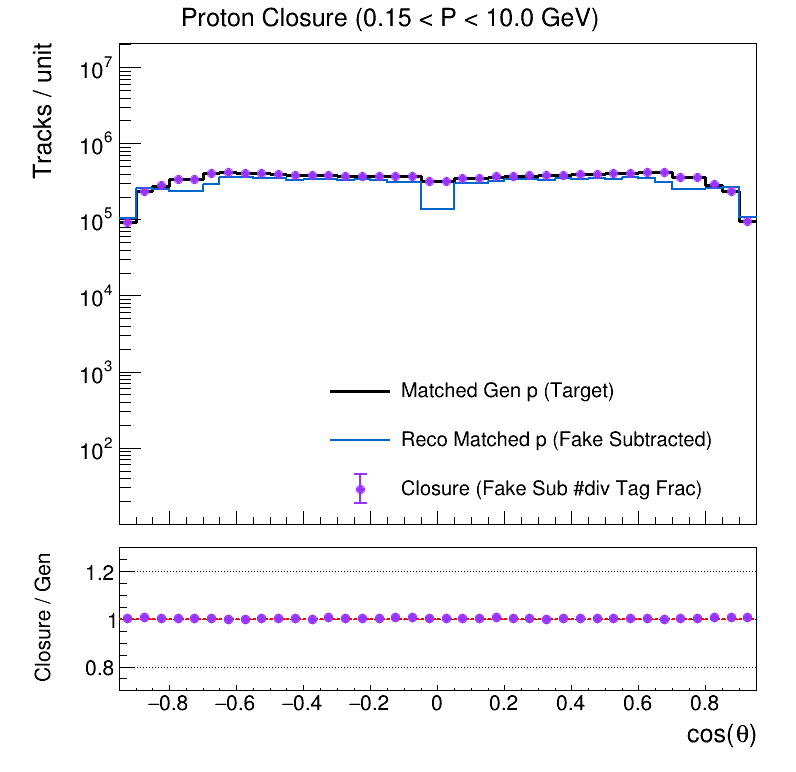

In [14]:
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetOptTitle(1)
ROOT.gStyle.SetErrorX(0)

closure_p_edges = np.array([
    0.00, 0.15, 0.25, 0.30, 0.35, 0.45, 0.50, 0.60, 0.718, 0.80, 0.90, 0.99, 1.00,
    1.10, 1.20, 1.30, 1.40, 1.50, 1.60, 1.80, 2.00, 2.20,
    2.30, 2.50, 2.60, 2.80, 2.90, 3.10, 3.30, 3.60, 4.00,
    4.50, 5.00, 5.50, 6.00, 6.50, 7.00, 7.50, 8.00
], dtype=np.float64)

closure_costh_edges = np.linspace(-0.95, 0.95, 39, dtype=np.float64)

def style_h(h, color, marker, lwidth=2):
    h.SetLineColor(color)
    h.SetMarkerColor(color)
    h.SetMarkerStyle(marker)
    h.SetMarkerSize(1.0)
    h.SetLineWidth(lwidth)

def reproject_y_xrange(h2d, new_y_edges, name, x_lo, x_hi):
    n_new = len(new_y_edges) - 1
    h1_out = ROOT.TH1D(name, name, n_new, new_y_edges)
    h1_out.Sumw2()
    for bx in range(1, h2d.GetNbinsX() + 1):
        cx = h2d.GetXaxis().GetBinCenter(bx)
        if not (x_lo < abs(cx) < x_hi): continue
        for by in range(1, h2d.GetNbinsY() + 1):
            y_lo_src = h2d.GetYaxis().GetBinLowEdge(by)
            y_hi_src = h2d.GetYaxis().GetBinUpEdge(by)
            content  = h2d.GetBinContent(bx, by)
            error    = h2d.GetBinError(bx, by)
            if content == 0: continue
            width_src = y_hi_src - y_lo_src
            for b_new in range(1, n_new + 1):
                y_lo_new = new_y_edges[b_new - 1]
                y_hi_new = new_y_edges[b_new]
                overlap_lo = max(y_lo_src, y_lo_new)
                overlap_hi = min(y_hi_src, y_hi_new)
                if overlap_hi <= overlap_lo: continue
                frac = (overlap_hi - overlap_lo) / width_src
                h1_out.SetBinContent(b_new, h1_out.GetBinContent(b_new) + content * frac)
                h1_out.SetBinError(b_new, np.sqrt(h1_out.GetBinError(b_new)**2 + (error * frac)**2))
    h1_out.Scale(1.0, "width")
    return h1_out

def reproject_x_yrange(h2d, new_x_edges, name, y_lo, y_hi):
    n_new = len(new_x_edges) - 1
    h1_out = ROOT.TH1D(name, name, n_new, new_x_edges)
    h1_out.Sumw2()
    for by in range(1, h2d.GetNbinsY() + 1):
        cy = h2d.GetYaxis().GetBinCenter(by)
        if not (y_lo < cy < y_hi): continue
        for bx in range(1, h2d.GetNbinsX() + 1):
            x_lo_src = h2d.GetXaxis().GetBinLowEdge(bx)
            x_hi_src = h2d.GetXaxis().GetBinUpEdge(bx)
            content  = h2d.GetBinContent(bx, by)
            error    = h2d.GetBinError(bx, by)
            if content == 0: continue
            width_src = x_hi_src - x_lo_src
            for b_new in range(1, n_new + 1):
                x_lo_new = new_x_edges[b_new - 1]
                x_hi_new = new_x_edges[b_new]
                overlap_lo = max(x_lo_src, x_lo_new)
                overlap_hi = min(x_hi_src, x_hi_new)
                if overlap_hi <= overlap_lo: continue
                frac = (overlap_hi - overlap_lo) / width_src
                h1_out.SetBinContent(b_new, h1_out.GetBinContent(b_new) + content * frac)
                h1_out.SetBinError(b_new, np.sqrt(h1_out.GetBinError(b_new)**2 + (error * frac)**2))
    h1_out.Scale(1.0, "width")
    return h1_out


def build_final_closure(species, proj="P", costh_lo=0.15, costh_hi=0.675,
                        p_lo=0.15, p_hi=10.0,
                        MAX_WEIGHT=1000.0, MIN_RATE=1e-6, MIN_TAGGED=0):
    other   = [s for s in particles if s != species]
    sp_sym  = {"pion": "#pi", "kaon": "K", "proton": "p"}[species]
    sp_name = species.capitalize()

    if proj.upper() == "P":
        edges        = closure_p_edges
        projector    = lambda h, name: reproject_y_xrange(h, edges, name, costh_lo, costh_hi)
        xtitle       = "P [GeV]"
        ytitle       = "Tracks / GeV"
        title_suffix = f"({costh_lo} < |cos#theta| < {costh_hi})"
    else:
        edges        = closure_costh_edges
        projector    = lambda h, name: reproject_x_yrange(h, edges, name, p_lo, p_hi)
        xtitle       = "cos(#theta)"
        ytitle       = "Tracks / unit"
        title_suffix = f"({p_lo} < P < {p_hi} GeV)"

    uid = f"{species}_{proj}"

    # Reco tagged + fake rate
    h_reco    = projector(reco_hists[species],        f"h_{uid}_reco")
    h_unmatch = projector(reco_unmatched_sp[species], f"h_{uid}_unmatch")

    h_fakerate = h_unmatch.Clone(f"h_{uid}_fakerate")
    h_fakerate.Divide(h_reco)   # fake_rate = unmatched / tagged


    #reco_matched = reco_tagged * (1 - fake_rate)  bin-by-bin
    h_rm = h_reco.Clone(f"h_{uid}_rm")
    for b in range(1, h_reco.GetNbinsX() + 1):
        rc   = h_reco.GetBinContent(b)
        rc_e = h_reco.GetBinError(b)
        fb   = h_fakerate.GetBinContent(b)
        rm   = rc * (1.0 - fb)
        rm_e = rc_e * (1.0 - fb)
        h_rm.SetBinContent(b, rm)
        h_rm.SetBinError(b,   rm_e)

    # Tag fraction, tf = gen_tagged_as_X (all true species) / gen_matched_true_X
    h_x2x        = projector(pid_tagged[f"{species}_tag_{species}"], f"h_{uid}_x2x")
    h_gen_tagged = h_x2x.Clone(f"h_{uid}_gen_tagged")
    for o in other:
        h_gen_tagged.Add(projector(pid_tagged[f"{o}_tag_{species}"], f"h_{uid}_{o[0]}2x"))

    h_eff      = projector(gen_matched[species], f"h_{uid}_eff")
    h_tag_frac = h_gen_tagged.Clone(f"h_{uid}_tagfrac")
    h_tag_frac.Divide(h_eff)
    for b in range(0, h_tag_frac.GetNbinsX() + 2):
        h_tag_frac.SetBinError(b, 0.0)


    # Closure = reco_matched / tag_frac  (bin-by-bin)
    h_closure = h_reco.Clone(f"h_{uid}_closure")
    for b in range(1, h_reco.GetNbinsX() + 1):
        rm   = h_rm.GetBinContent(b)
        rm_e = h_rm.GetBinError(b)
        tf   = h_tag_frac.GetBinContent(b)
        gt   = h_gen_tagged.GetBinContent(b)

        if tf > MIN_RATE and gt >= MIN_TAGGED:
            w = min(1.0 / tf, MAX_WEIGHT)
            h_closure.SetBinContent(b, rm * w)
            h_closure.SetBinError(b,   rm_e * w)
        else:
            h_closure.SetBinContent(b, 0.0)
            h_closure.SetBinError(b,   0.0)

    h_ratio = h_closure.Clone(f"h_{uid}_ratio")
    h_ratio.Divide(h_eff)


    style_h(h_eff,      ROOT.kBlack,    20, lwidth=3)
    style_h(h_rm,       ROOT.kAzure+2,  21, lwidth=2)
    style_h(h_closure,  ROOT.kViolet+1, 20, lwidth=2)
    style_h(h_ratio,    ROOT.kViolet+1, 20, lwidth=2)


    c = ROOT.TCanvas(f"c_{uid}", f"{sp_name} {proj} Closure", 800, 800)

    ptop = ROOT.TPad(f"ptop_{uid}", "", 0.0, 0.30, 1.0, 1.0)
    ptop.SetBottomMargin(0.03); ptop.SetLeftMargin(0.15)
    ptop.SetRightMargin(0.05); ptop.SetTopMargin(0.08); ptop.SetLogy()
    ptop.Draw(); ptop.cd()

    h_eff.SetMinimum(1e1)
    h_eff.SetMaximum(h_eff.GetMaximum() * 50)
    h_eff.SetTitle(f"{sp_name} Closure {title_suffix}")
    h_eff.GetXaxis().SetLabelSize(0)
    h_eff.GetYaxis().SetTitle(ytitle)
    h_eff.GetYaxis().SetTitleSize(0.05)
    h_eff.GetYaxis().SetLabelSize(0.045)
    h_eff.GetYaxis().SetTitleOffset(1.2)

    h_eff.Draw("HIST")
    h_rm.Draw("HIST SAME")        # fake-subtracted reco (replaces h_tagged_matched)
    h_closure.Draw("E1 X0 SAME")

    leg = ROOT.TLegend(0.40, 0.05, 0.82, 0.32)
    leg.SetBorderSize(0); leg.SetFillStyle(0); leg.SetTextSize(0.04)
    leg.AddEntry(h_eff,     f"Matched Gen {sp_sym} (Target)", "l")
    leg.AddEntry(h_rm,      f"Reco Matched {sp_sym} (Fake Subtracted)", "l")
    leg.AddEntry(h_closure, f"Closure (Fake Sub #div Tag Frac)", "pe")
    leg.Draw()

    c.cd()
    pbot = ROOT.TPad(f"pbot_{uid}", "", 0.0, 0.0, 1.0, 0.30)
    pbot.SetTopMargin(0.03); pbot.SetBottomMargin(0.35)
    pbot.SetLeftMargin(0.15); pbot.SetRightMargin(0.05); pbot.SetGridy()
    pbot.Draw(); pbot.cd()

    h_ratio.SetTitle("")
    h_ratio.GetXaxis().SetTitle(xtitle)
    h_ratio.GetXaxis().SetTitleSize(0.12); h_ratio.GetXaxis().SetLabelSize(0.10)
    h_ratio.GetXaxis().SetTitleOffset(1.0)
    h_ratio.GetYaxis().SetTitle("Closure / Gen")
    h_ratio.GetYaxis().SetRangeUser(0.7, 1.3)
    h_ratio.GetYaxis().SetNdivisions(505)
    h_ratio.GetYaxis().SetTitleSize(0.10); h_ratio.GetYaxis().SetLabelSize(0.10)
    h_ratio.GetYaxis().SetTitleOffset(0.6)

    h_ref = h_ratio.Clone(f"ref_{uid}")
    for b in range(0, h_ref.GetNbinsX() + 2):
        h_ref.SetBinContent(b, 1.0); h_ref.SetBinError(b, 0.0)
    h_ref.SetLineColor(ROOT.kRed); h_ref.SetLineStyle(2)
    h_ref.SetLineWidth(2); h_ref.SetMarkerSize(0)

    h_ratio.Draw("E1 X0")
    h_ref.Draw("HIST SAME")
    h_ratio.Draw("E1 X0 SAME")

    c.Draw()
    keep_alive.extend([c, ptop, pbot, leg,
                       h_reco, h_unmatch, h_fakerate, h_rm,
                       h_gen_tagged, h_eff, h_tag_frac,
                       h_closure, h_ratio, h_ref])

    tg_tot   = h_reco.Integral("width")
    rm_tot   = h_rm.Integral("width")
    fr_glob  = (tg_tot - rm_tot) / tg_tot if tg_tot > 0 else 0.0
    eff_int  = h_eff.Integral("width")
    cl_int   = h_closure.Integral("width")
    ratio_val = cl_int / eff_int if eff_int > 0 else 0.0

    #print(f"\n{'='*55}")
    #print(f"{species.upper()} CLOSURE ({proj} projection)")
    #print(f"{'='*55}")
    #print(f"  reco tagged              : {tg_tot:.2f}")
    #print(f"  reco fake-subtracted     : {rm_tot:.2f}")
    #print(f"  global fake rate         : {fr_glob:.4f}")
    #print(f"  gen_matched (target)     : {eff_int:.2f}")
    #print(f"  closure integral         : {cl_int:.2f}")
    #print(f"  closure / gen_matched    : {ratio_val:.4f}  <- should be ~1")
    #print(f"{'='*55}")

    print(f"[{species.upper():<6}] {proj:>5}-projection Global Ratio = {ratio_val:.4f}")

    return c, ratio_val


keep_alive = []

print("\n--- Generating Momentum (P) Plots ---")
c_pi_p, r_pi_p = build_final_closure("pion",   proj="P")
c_k_p,  r_k_p  = build_final_closure("kaon",   proj="P")
c_pr_p, r_pr_p = build_final_closure("proton", proj="P")

print("\n--- Generating Angular (cosTheta) Plots ---")
c_pi_ct, r_pi_ct = build_final_closure("pion",   proj="costh")
c_k_ct,  r_k_ct  = build_final_closure("kaon",   proj="costh")
c_pr_ct, r_pr_ct = build_final_closure("proton", proj="costh")